In [1]:
import pandas as pd
import numpy as np
import statsmodels.tsa.api as smt
#tsa为Time Series analysis缩写
import statsmodels.api as sm
import scipy.stats as scs
from arch import arch_model
#画图模块
import matplotlib.pyplot as plt
import matplotlib as mpl
#正常显示画图时出现的中文以及负号
from pylab import mpl
#设置了 matplotlib 使用 "SimHei" 字体作为默认的无衬线字体
mpl.rcParams['font.sans-serif']=['SimHei']
#设置了 matplotlib 在坐标轴上显示负号时不使用 Unicode 编码
mpl.rcParams['axes.unicode_minus']=False

In [3]:
def ts_plot(data, lags=None,title=''):
    if not isinstance(data, pd.Series):   
        data = pd.Series(data)
    #matplotlib官方提供了五种不同的图形风格，
    #包括bmh、ggplot、dark_background、fivethirtyeight和grayscale
    with plt.style.context('ggplot'):    
        fig = plt.figure(figsize=(10, 8))
        layout = (3, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))
        qq_ax = plt.subplot2grid(layout, (2, 0))
        pp_ax = plt.subplot2grid(layout, (2, 1))
        data.plot(ax=ts_ax)
        ts_ax.set_title(title+'时序图')
        smt.graphics.plot_acf(data, lags=lags, ax=acf_ax, alpha=0.5)
        acf_ax.set_title('自相关系数')
        smt.graphics.plot_pacf(data, lags=lags, ax=pacf_ax, alpha=0.5)
        pacf_ax.set_title('偏自相关系数')
        sm.qqplot(data, line='s', ax=qq_ax)
        qq_ax.set_title('QQ 图')        
        scs.probplot(data, sparams=(data.mean(), 
                     data.std()), plot=pp_ax)
        pp_ax.set_title('PP 图') 
        plt.tight_layout()
    return

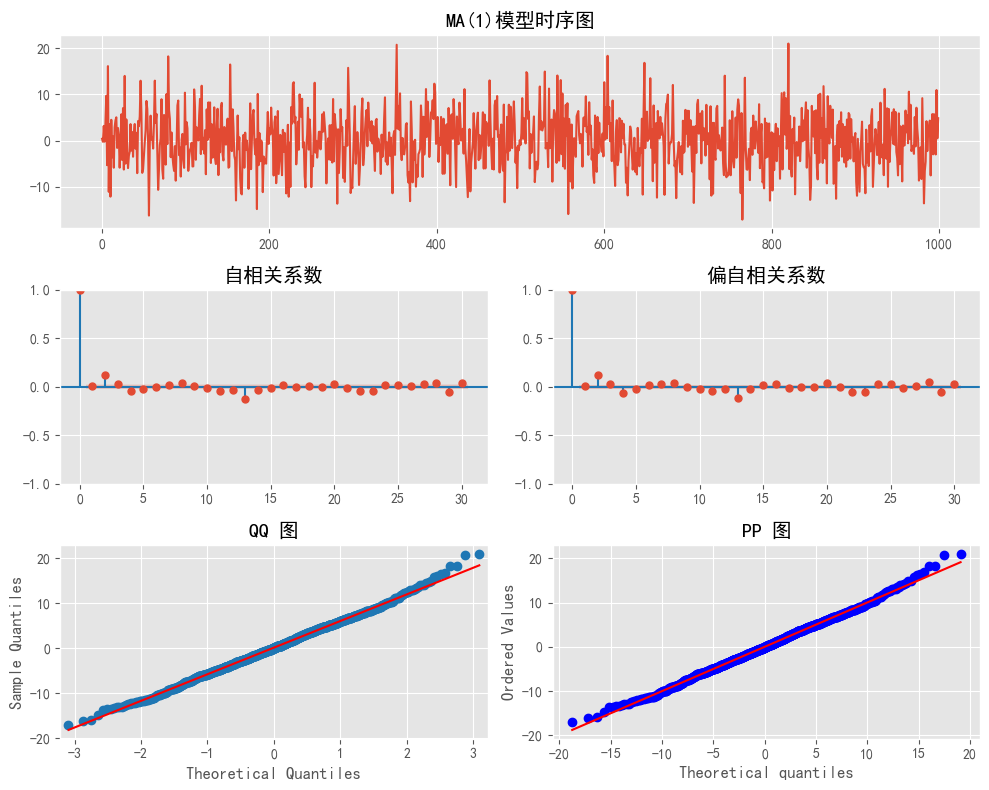

In [5]:
#使用arma模型模拟ma模型，设定ar阶数为0，即得到ma模型
alphas=np.array([0.])
betas=np.array([0,6])
ar=np.r_[1,-alphas]
ma=np.r_[1,betas]
ma_sample=smt.arma_generate_sample(ar=ar,ma=ma,nsample=1000)
ts_plot(ma_sample,lags=30,title='MA(1)模型')

In [7]:
#估计数据的AR模型参数和滞后阶数
def simu_ar(data,a,maxlag=30,true_order=1):
    #'''data:要拟合的数据；a为参数,可以为列表；maxlag:最大滞后阶数'''
    #拟合AR(P)模型
    result=smt.AR(data).fit(maxlag=maxlag,ic='aic',trend='nc')
    #选择滞后阶数
    est_order=smt.AR(data).select_order(maxlag=maxlag,ic='aic',trend='nc')
    #参数选择标准ic：有四个选择{‘aic’，‘bic’，‘hqic’，‘t-stat’}
    #趋势项：trend：c是包含常数项，nc不包含常数项
    #打印结果
    print(f'参数估计值:{result.params.round(2)},估计的滞后性阶数:{est_order}')
    print(f'真实参数值:{a},真实滞后阶数:{true_orderorder}')
simu_ar(x,a=0.8)

NameError: name 'x' is not defined

In [8]:
# 对上述模拟数据进行ARMA模型拟合
max_lag = 30
result = smt.ARMA(ma1, order=(0, 1)).fit(maxlag=max_lag, 
             method='mle', trend='nc')
print(result.summary())

AttributeError: module 'statsmodels.tsa.api' has no attribute 'ARMA'